# Fund Workstation

### Setting Up the Environment

In [1]:
import pandas as pd
import plotly.graph_objects as go
from src.fofproject.fund import Fund, input_monthly_returns, subset_of_funds, compare_funds
from fofproject.batch import plot_cumulative_returns, plot_fund_correlation_heatmap
from src.fofproject.mvo import minimum_variance_analysis
from src.fofproject.load import load_saved_json, init_funds, process_pdfs_in_folder, save_changes_in_fund, merge_funds

# Names of our portfolio & benchmark indices
our_portfolio = ['TAIREN','HAO','LEXINGTON','LIM','FOREST','WT LS','E20','3W GLOBAL','3W CHINA','3W HEALTHCARE','TIMEFOLIO','MONOLITH','PERSEVERANCE','NEO IVY','JH BIOTECH']
our_index = ['MSCI CHINA','TOPIX','S&P 500','MSCI WORLD', 'EUREKAHEDGE']

#### Load Data via .json

In [48]:
test = load_saved_json(folder_path=r"input\portfolio")
print(type(test))
funds = init_funds(test)

<class 'list'>


#### Load Data via .csv

In [49]:
# Use for manually update csv data and merge with json file 

csv_fund = input_monthly_returns(r"RETURN DATA.csv")



#### GPT Input Factsheet

In [52]:
gpt_fund = process_pdfs_in_folder(folder_path=r"input\test",save=True)
gpt_fund = init_funds(gpt_fund)

Processing: input\test\ARVIN_US_EquityLS_low net_13.6%rtn 10.31%vol.pdf
text parsing - the result is {
  "fund_name": "ARVIN",
  "fund_des": "ARVIN is a hedge fund focused on equity long-short with opportunistic credit, led by CIO Rohan Varavadekar with 20 years of experience. The fund targets 30%-65% net exposure and 100%-250% gross exposure, investing across consumer, industrials, TMT, technology, and energy sectors primarily in North America and globally. It employs deep underwriting, IRR-based idea evaluation, and tactical SPVs for unique market dislocations. Rated 4 for its diversified strategy and experienced management.",
  "performance": {
    "table": [
      ["Year", "01/01", "01/02", "01/03", "01/04", "01/05", "01/06", "01/07", "01/08", "01/09", "01/10", "01/11", "01/12", "YTD"],
      ["2025", "0.022", "0.008", "-0.043", "-0.013", "0.036", "0.032", "", "", "", "", "", "", "0.0404"],
      ["2024", "0", "0.015", "0.054", "-0.03", "0.0003", "-0.009", "0.036", "-0.003", "0.033

#### Process Input

In [ ]:
# Use the former file's performance data to update the latter one
funds = merge_funds(csv_fund, funds)



#### Save the Changes

In [53]:
# Careful what fund you are saving to what folder
save_changes_in_fund(gpt_fund, folder_path=r"input\test")

⚠️ Skipping BOYU CAPITAL (no performance data).
⚠️ Skipping ACM GLOBAL (no performance data).
⚠️ Skipping GOLDEN PINE (no performance data).
⚠️ Skipping NEO IVY (no performance data).
🔄 Existing CSV found. Updated with new data and saved to input\test\returns.csv


### Compare Multiple Funds

In [ ]:
df = compare_funds(funds)
df = df[~df["Name"].isin(our_index)].reset_index(drop=True)
hongkong_df = df[df["Contact"].apply(
    lambda x: isinstance(x, dict) and x.get("location") == "Hong Kong"
)]
hongkong_df

,Name,Description,Location,Strategy,Sector,Managers,Contact,AUM,Net Exposure,Net Return,...,Inception Date,Latest Date,# Months,Cumulative Return,Annualized Return,Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown,Positive Months
0,3W CHINA,3W Greater China Focus Fund is a long/short eq...,[apac],[equity_ls],[equity_diversified],None,"{'name': '', 'location': 'Hong Kong', 'email':...",920.52,[0.2325],True,...,2012-03-01,2025-08-01,162,4.133456,0.128815,0.074835,1.721337,3.696521,0.096000,0.691358
1,3W GLOBAL,3W Global Fund is a long/short equity fund man...,[apac],[equity_ls],[equity_diversified],3W Fund Management Limited,"{'name': '', 'location': 'Hong Kong', 'email':...",2160.97,[0.2101],True,...,2015-02-01,2025-08-01,127,6.384341,0.207940,0.131453,1.581857,4.632756,0.106092,0.692913
2,3W HEALTHCARE,3W Healthcare Fund is a healthcare-focused equ...,[apac],[equity_ls],[equity_healthcare],3W Fund Management Limited,"{'name': '', 'location': 'Hong Kong', 'email':...",86.42,[0.3614],True,...,2021-02-01,2025-08-01,55,0.103619,0.021745,0.206779,0.105159,0.143744,0.544285,0.600000
3,E20,E20 Global Opportunity Investment Fund launche...,"[apac, north_america, europe]",[equity_ls],"[equity_TMT, equity_consumer, equity_finance, ...",None,"{'name': '', 'location': 'Hong Kong', 'email':...",190.00,[0.27],False,...,2025-07-01,2025-08-01,2,0.206667,2.086908,0.180282,11.575769,NaN,0.000000,1.000000
5,HAO,HAO is a China-focused equity long-short fund ...,[apac],[equity_ls],[equity_diversified],None,"{'name': '', 'location': 'Hong Kong', 'email':...",1728.57,[-0.1534],True,...,2014-08-01,2025-08-01,133,26.082488,0.346682,0.264270,1.311849,2.888728,0.211048,0.639098
9,MONOLITH,Monolith is a long/short public equity fund fo...,"[apac, north_america, europe]",[equity_ls],[equity_TMT],Tim Wang,"{'name': 'Tim Wang', 'location': 'Hong Kong', ...",0.00,[0.6888],True,...,2022-02-01,2025-08-01,43,1.113684,0.232278,0.173465,1.339050,3.072912,0.133407,0.651163
13,TAIREN,TAIREN is a global long/short equity fund aimi...,[global],[equity_ls],equity_diversified,"Larry CHEN, Muye XU","{'name': '', 'location': 'Hong Kong', 'email':...",0.00,[-0.06],True,...,2007-05-01,2025-08-01,220,32.772004,0.211646,0.174764,1.211038,2.444443,0.179276,0.672727


In [32]:
# Combine all conditions in a single filter
mask = (df["Sharpe Ratio"] > 1) & (df["Annualized Return"] > 0.1) & (df["AUM"] > 10) 

# Column List = ["Name", "Description", "Location", "Strategy", "Sector", "Managers", "Contact", "AUM", 
#                     "Net Exposure", "Net Return", "Mgmt Fee", "Perf Fee", "Inception Date", "Latest Date", 
#                     "# Months", "Cumulative Return", "Annualized Return", "Volatility", "Sharpe Ratio", 
#                     "Sortino Ratio", "Max Drawdown", "Positive Months"]

# Then, select only the columns you want
df['Worth a Look'] = mask
filtered = df[["Worth a Look","Name", "Location","Strategy", "AUM", "Sharpe Ratio", "Annualized Return", "Max Drawdown","Description"]]
filtered

,Worth a Look,Name,Location,Strategy,AUM,Sharpe Ratio,Annualized Return,Max Drawdown,Description
0,True,3W CHINA,[apac],[equity_ls],920.52,1.721337,0.128815,0.096000,3W Greater China Focus Fund is a long/short eq...
1,True,3W GLOBAL,[apac],[equity_ls],2160.97,1.581857,0.207940,0.106092,3W Global Fund is a long/short equity fund man...
2,False,3W HEALTHCARE,[apac],[equity_ls],86.42,0.105159,0.021745,0.544285,3W Healthcare Fund is a healthcare-focused equ...
3,True,E20,"[apac, north_america, europe]",[equity_ls],190.00,11.575769,2.086908,0.000000,E20 Global Opportunity Investment Fund launche...
4,False,FOREST,[global],"[special_situation, event_driven]",0.00,2.009474,0.178589,0.088300,FOREST is an absolute return fund focusing on ...
5,True,HAO,[apac],[equity_ls],1728.57,1.311849,0.346682,0.211048,HAO is a China-focused equity long-short fund ...
6,True,JH BIOTECH,[north_america],[equity_ls],2700.00,1.638859,0.387212,0.223271,The Biotechnology Innovation Fund focuses on c...
7,True,LEXINGTON,[north_america],[equity_ls],16521.25,1.680974,0.248003,0.108453,LEXINGTON is an equity and option fund managed...
8,True,LIM,[apac],"[activists, special_situation]",152300.00,2.523314,0.177308,0.087128,The LIM Japan Event Fund focuses on corporate ...
9,False,MONOLITH,"[apac, north_america, europe]",[equity_ls],0.00,1.339050,0.232278,0.133407,Monolith is a long/short public equity fund fo...


In [ ]:
filtered.to_csv("output/funds_comparison.csv", index=False)

#### Compare Performance Table

In [30]:
funds['RDGFF'].export_monthly_table(benchmark_fund = funds['MSCI CHINA'], benchmark_name = "MSCI\nChina" ,language = "en", inception_column = True)
funds['RDGFF'].export_monthly_table(benchmark_fund = funds['MSCI WORLD'], benchmark_name = "MSCI\nWorld" ,language = "en", inception_column = True)

KeyError: 'month'

#### Plot Cumulative Return

In [13]:

funds_to_be_plot = subset_of_funds(funds, ['3W CHINA', 'EUREKAHEDGE','MSCI CHINA'])
start_month = "2007-12"
end_month = "2024-7"

plot = plot_cumulative_returns(
    funds=funds_to_be_plot,
    title="",
    start_month=start_month,
    end_month=end_month,
    style="excel",
    language="en",
    blur=True,
    aspect_lock=True,
    custom_ticks=False,
    save=False,
    toggle=False
    )


### Correlation Heat Map

In [9]:
# Correlation heatmap

funds_to_be_plot = funds
start_month = "2019-12"
end_month = "2020-7"

fig, corr_df, overlap_df = plot_fund_correlation_heatmap(funds_to_be_plot, method="pearson", min_overlap=12)

### Summary of a Fund

3W Greater China Focus Fund is a long/short equity fund focusing on Greater China markets with a net long exposure of 23.25%. It emphasizes TMT and financial sectors with active management of long and short positions. The fund has a strong risk-adjusted return profile with a Sharpe ratio of 1.45 and Sortino ratio of 3.12. Managed by 3W Fund Management Limited, it charges a 2% management fee and 20% performance fee. Rated 4 for its focused regional strategy and consistent performance.
Net Exposure = 23.25% to 23.25%
{'name': '', 'location': 'Hong Kong', 'email': 'ir@3wfund.com', 'number': '(852) 2597 3182'}


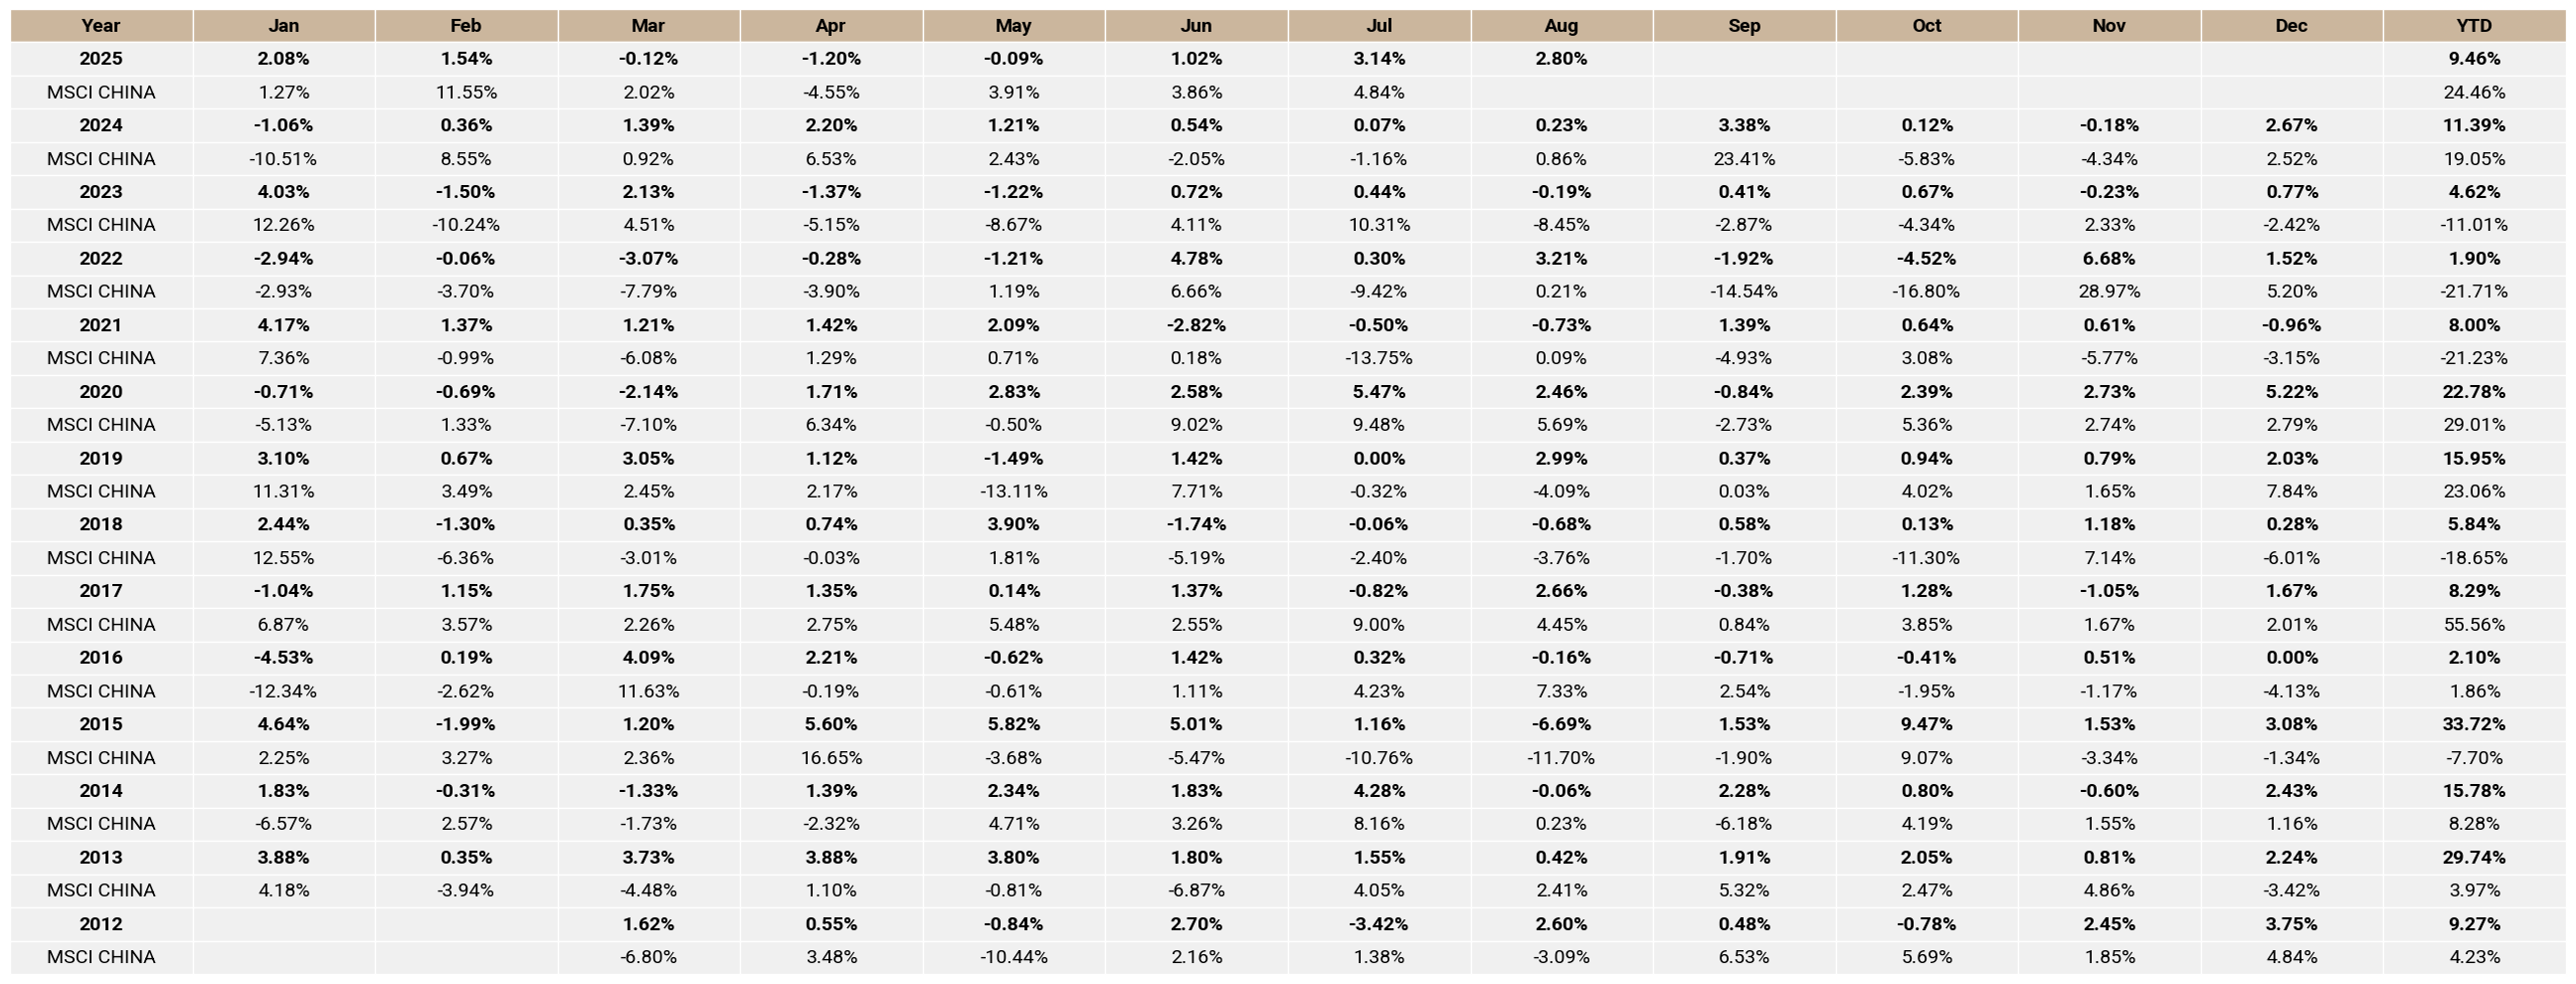

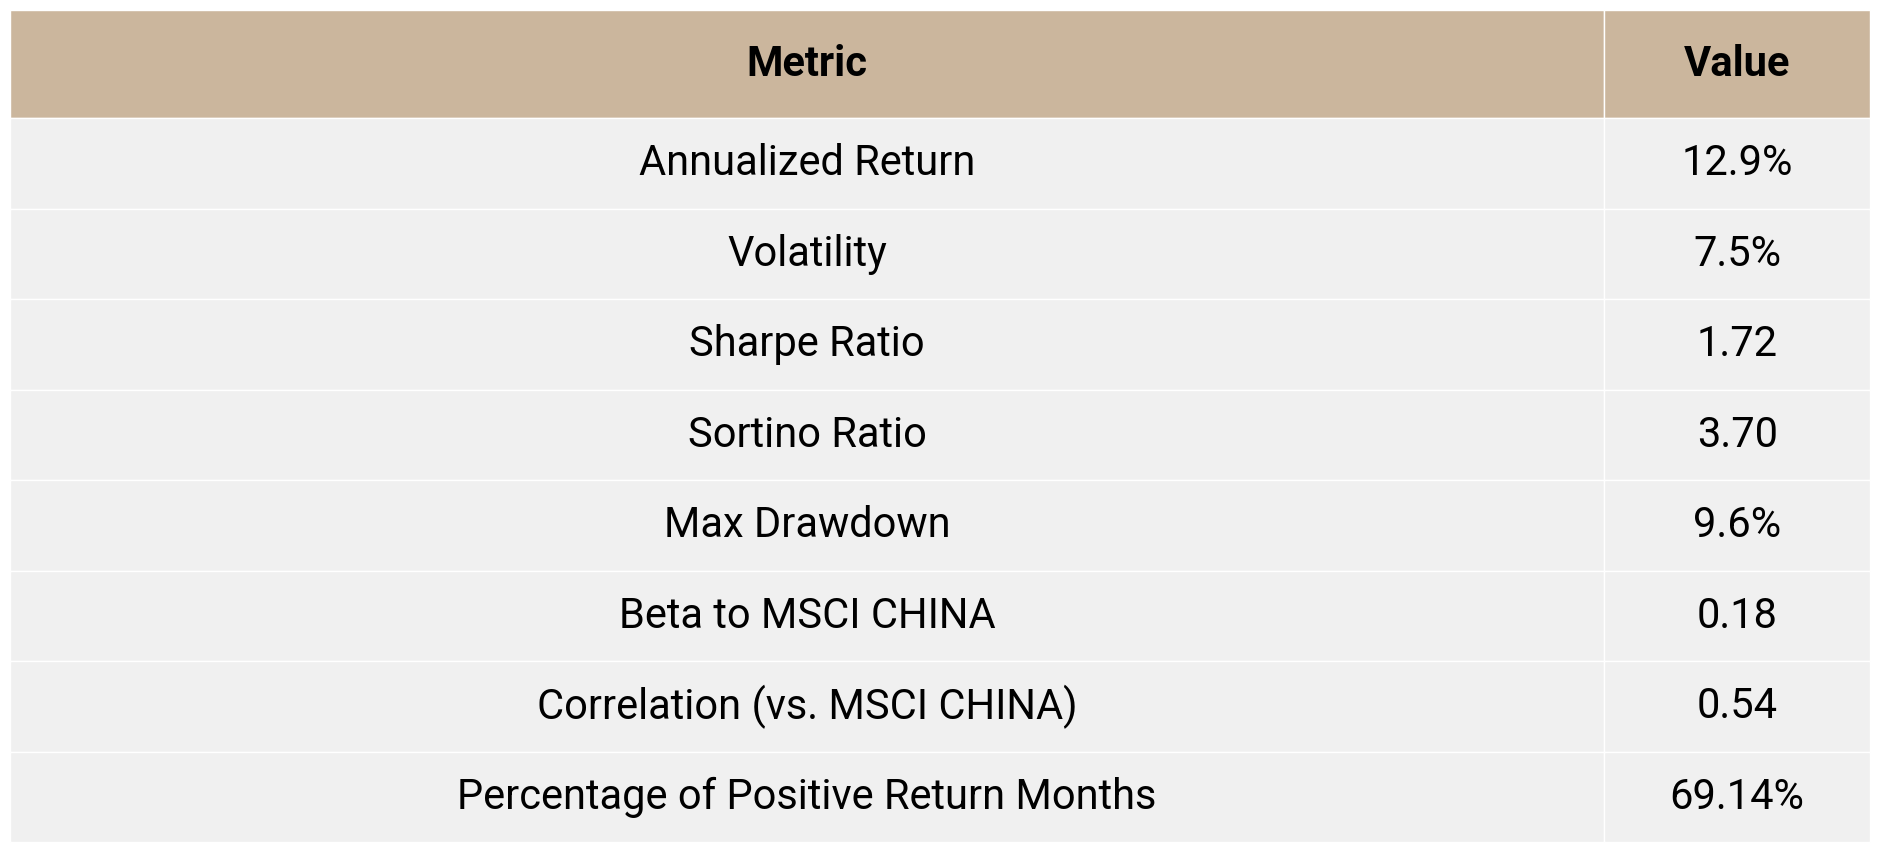

C:\Users\FOF Analyst\Desktop\fofproject\src\fofproject\fund.py:1452: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



In [14]:
funds['3W CHINA'].summary_of_a_fund(benchmark_fund=funds['MSCI CHINA'],language="en")

#### Quick Investigation

In [ ]:
the_fund_to_investigate = funds['RDGFF']
benchmark_fund = funds['MSCI CHINA']
# The List = ["cagr","vol","sharpe","sortino","mdd","beta","corr","win","best","worst","aum","skew","kurt","turnover"]

fig = the_fund_to_investigate.export_key_metrics_table(
            benchmark_fund=benchmark_fund,
            end_month=the_fund_to_investigate.latest_date,
            language="en",
            metrics=["cagr", "vol", "sharpe", "sortino", "mdd", "beta", "corr", "win"],
            horizontal=False,
        )